Within this notebook, we explore the application of DAG Convolutional Network (DC) to solve a source identification problem. The dataset is generated from an input signal predominantly zero across all nodes except for a single designated node. This input signal is then diffused across the DAG. Subsequently, our objective is to accurately discern the node responsible for originating the signals based on the output data.


In [1]:
import numpy as np
import time
import dgl
import torch
from torch.nn import functional as F
from torch import nn
import networkx as nx
from tqdm.auto import tqdm

import src.dag_utils as dagu
import src.utils as utils
from src.arch import DAGConv, FB_DAGConv, SF_DAGConv, ADCN, NodeParallelMLPSum, NodeSharedMLPSum
from src.models import SrcIdModel, LinDAGClassModel, MultiSrcIdModel
from src.baselines_archs import MyGCNN, GAT, MLP, GraphSAGE, GIN

# Ser random seed
SEED = 10
PATH = 'results/multi_src_id/'
SAVE = True
np.random.seed(SEED)
torch.manual_seed(SEED)
dgl.random.seed(SEED)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


### Default parameters and auxiliary functions

In [2]:
M = 2000

data_p = {
    'n_tries': 5,  #25,

    ## Graph parameters
    'p': 0.2,                    # Edge prob in Erdos-Renyi DAG
    'N': 100,                    # Number of nodes

    ## Signal parameters
    'M': M,                   # Number of observed signals
    'M_train': int(0.7 * M),  # Samples selected for training
    'M_val': int(0.2 * M),    # Samples selected for validation
    'M_test': int(0.1 * M),   # Samples selected for test
    'src_t': 'random',          # 'random' or 'constant'
    'max_src_node': 20,  # 10           # Maximum index of nodes allowed to be sources
    'n_sources': 1,              # Maximum Number of source nodes
    'n_p_y': .05,  
    'n_p_x': 0,                  # Normalized noise power
    'max_GSO': 100,              # Maximum index of GSOs involved in the diffusion
    'min_GSO': 50,               # Minimum index of GSOs involved in the diffusion
    'n_GSOs': 25                 # Number of GSOs
}

# Model parameters
default_arch_args = {
    'in_dim': 1,        # Input dimension
    'hid_dim': 32,     # Hidden dimension
    'out_dim': 1,       # Output dimension
    'n_layers': 2,  # 3 also works well          # Number of layers
    'l_act': None,
}

default_mod_p = {
    'bs': 25,           # Size of the batch
    'lr': 5e-3,         # Learning rate
    'epochs': 200,  # 50,       # Number of training epochs 
    'pat': 25,  # 15,          # Number of non-decreasing epoch to stop training
    'wd': 1e-4,         # Weight decay
}

In [3]:
def get_signals(d_p, GSOs, get_srcs=False):
    range_GSO = np.arange(d_p['min_GSO'], d_p['max_GSO'])
    gsos_idx = np.random.choice(range_GSO, size=d_p['n_GSOs'], replace=False)
    sel_GSOs = GSOs[gsos_idx]
    signals_t, srcs_t, _ = dagu.create_diff_data(d_p['M'], sel_GSOs, d_p['max_src_node'], d_p['n_p_x'],
                                                 d_p['n_p_y'], d_p['n_sources'], src_t=d_p['src_t'],
                                                 torch_tensor=True, mask_sources=True)
    # Changed to multi-hot encoding
    labels_t = (torch.abs(srcs_t) > 0).float()

    signals = {'train': signals_t[:d_p['M_train']], 'val': signals_t[d_p['M_train']:-d_p['M_test']],
                 'test': signals_t[-d_p['M_test']:]}
    labels = {'train': labels_t[:d_p['M_train']], 'val': labels_t[d_p['M_train']:-d_p['M_test']],
              'test': labels_t[-d_p['M_test']:]}
    
    if get_srcs:
        srcs = {'train': srcs_t[:d_p['M_train']], 'val': srcs_t[d_p['M_train']:-d_p['M_test']],
              'test': srcs_t[-d_p['M_test']:]}
        
        return signals, labels, sel_GSOs, srcs
    
    return signals, labels, sel_GSOs


def run_exp(d_p, d_arc_args, d_mod_p, exps, verb=False):
    acc = np.zeros((d_p['n_tries'], len(exps)))
    rec = np.zeros((d_p['n_tries'], len(exps)))
    times = np.zeros((d_p['n_tries'], len(exps)))

    t_begin = time.time()
    with tqdm(total=d_p['n_tries']*len(exps), disable=False) as pbar:
        for i in range(d_p['n_tries']):
            Adj, W, GSOs, Psi = utils.get_graph_data(d_p, get_Psi=True)
            signals, labels, sel_GSOs, srcs = get_signals(d_p, GSOs, get_srcs=True)

            for j, exp in enumerate(exps):
                # Combine default and experiment parameters    
                arc_p = {**exp['arc_p']}
                arc_p['args'] = {**d_arc_args, **arc_p['args']} if 'args' in arc_p.keys() else {**d_arc_args}
                mod_p = {**d_mod_p, **exp['mod_p']} if 'mod_p' in exp.keys() else d_mod_p

                if arc_p['arch'] == LinDAGClassModel:
                    # Combine default and experiment parameters    
                    if 'transp' in arc_p.keys() and arc_p['transp']:
                        dag_T = nx.from_numpy_array(Adj, create_using=nx.DiGraph())
                        Psi = np.array([dagu.compute_Dq(dag_T, i, d_p['N']) for i in range(d_p['N'])]).T
                        arc_p['transp'] = False

                    Psi_sel = utils.select_GSO(arc_p, Psi.T, None, W, Adj).numpy().T
                    lin_model = LinDAGClassModel(W, Psi_sel)
                    t_i = time.time()
                    lin_model.fit(signals['train'], srcs['train'])
                    t_e = time.time() - t_i

                    acc[i,j] = lin_model.test(signals['test'], labels['test'])
                
                else:
                    # Fit and test nonlinear models
                    GSO = utils.select_GSO(arc_p, GSOs, sel_GSOs, W, Adj)
                    K = GSO.shape[0] if isinstance(GSO, torch.Tensor) and len(GSO.shape) == 3 else 0 
                    arch = utils.instantiate_arch(arc_p, K)
                    # Use MultiSrcIdModel here
                    model = MultiSrcIdModel(arch, device=device)

                    t_i = time.time()
                    model.fit(signals, labels, GSO, mod_p['lr'], mod_p['epochs'], mod_p['bs'], mod_p['wd'], patience=mod_p['pat'])
                    t_e = time.time() - t_i

                    acc[i,j], rec[i,j] = model.test(signals['test'], labels['test'], GSO, k=d_p['n_sources'])
                times[i,j] = t_e

                # Progress
                pbar.update(1)
                if verb:
                    print(f'-{i}. {exp["leg"]}: acc: {acc[i,j]:.3f} - rec: {rec[i,j]:.3f} - time: {times[i,j]:.1f}')
    
    total_t = (time.time() - t_begin)/60
    print(f'----- Ellapsed time: {total_t:.2f} minutes -----')
    return acc, rec, times


def run_exps(exps, d_arc_args, d_mod_p, d_dat_p, GSOs, W, Adj, pbar, verb=True, exp_desc='default'):
    # Create error variables
    acc_exps = np.zeros(len(exps))
    rec_exps = np.zeros(len(exps))
    times_exps = np.zeros(len(exps))
    
    common_signals = all('dat_p' not in exp for exp in exps)
    if common_signals:
        signals, labels, sel_GSOs = get_signals(d_dat_p, GSOs)
    
    for k, exp in enumerate(exps):
        # Combine default and experiment parameters
        arc_p = {**exp['arc_p']}
        arc_p['args'] = {**d_arc_args, **arc_p['args']} if 'args' in arc_p.keys() else {**d_arc_args}
        mod_p = {**d_mod_p, **exp['mod_p']} if 'mod_p' in exp else d_mod_p

        if not common_signals:
            d_dat_p_exp = {**d_dat_p, **exp['dat_p']}
            signals, labels, sel_GSOs = get_signals(d_dat_p_exp, GSOs)

        GSO = utils.select_GSO(arc_p, GSOs, sel_GSOs, W, Adj)
        K = GSO.shape[0] if isinstance(GSO, torch.Tensor) and len(GSO.shape) == 3 else 0 
        arch = utils.instantiate_arch(arc_p, K)
        model = MultiSrcIdModel(arch, device=device)
        
        t_i = time.time()
        model.fit(signals, labels, GSO, mod_p['lr'], mod_p['epochs'], mod_p['bs'], mod_p['wd'],
                  patience=mod_p['pat'])
        t_e = time.time() - t_i
        
        acc_exps[k], rec_exps[k] = model.test(signals['test'], labels['test'], GSO, k=d_dat_p.get('n_sources', 1))
        times_exps[k] = t_e

        # Progress
        pbar.update(1)
        if verb:
            print(f'	-{exp_desc}. {exp["leg"]}: acc: {acc_exps[k]:.3f} - rec: {rec_exps[k]:.3f} - time: {times_exps[k]:.1f}')

    return acc_exps, rec_exps, times_exps

## Initial Test - As classification problem

In [ ]:
mod_p_init = default_mod_p.copy()
mod_p_init['pat'] = 50  # 100
verb = True

Exps = [
    # Our Models - Transposed
    {'arc_p': {'arch': NodeParallelMLPSum, 'GSO': 'GSOs', 'transp': True}, 'leg': 'PDCN'},
    {'arc_p': {'arch': NodeSharedMLPSum, 'GSO': 'GSOs', 'transp': True}, 'leg': 'SharedPDCN'},

    {'arc_p': {'arch': FB_DAGConv, 'GSO': 'GSOs', 'transp': True}, 'leg': 'DCN-T'},
    {'arc_p': {'arch': FB_DAGConv, 'GSO': 'rnd_GSOs', 'n_gsos': 30, 'transp': True}, 'leg': 'DCN-30-T'},

    # GNN Baselines
    {'arc_p': {'arch': FB_DAGConv, 'GSO': 'A_pows', 'K': 2, 'transp': True}, 'leg': 'FB-GCNN-2'},
    {'arc_p': {'arch': FB_DAGConv, 'GSO': 'A_pows', 'K': 3, 'transp': True}, 'leg': 'FB-GCNN-3'},
    {'arc_p': {'arch': FB_DAGConv, 'GSO': 'A_pows', 'K': 5, 'transp': True}, 'leg': 'FB-GCNN-5'},
    {'arc_p': {'arch': MyGCNN, 'GSO': 'A', 'transp': True}, 'leg': 'GNN-A'},
    {'arc_p': {'arch': GAT, 'GSO': 'A-dgl', 'transp': True, 'args': {'num_heads': 2, 'hid_dim': 16,
     'gat_params': {'attn_drop': 0}}}, 'leg': 'GAT'},
    {'arc_p': {'arch': GraphSAGE, 'GSO': 'A-dgl', 'transp': True, 'args': {'aggregator': 'mean'}}, 'leg': 'GraphSAGE-A'},
    {'arc_p': {'arch': GIN, 'GSO': 'A-dgl', 'transp': True, 'args': {'aggregator': 'sum'}}, 'leg': 'GIN-A'},
    {'arc_p': {'arch': GIN, 'GSO': 'A-dgl', 'transp': True, 'args': {'aggregator': 'sum', 'mlp_layers': 4}}, 'leg': 'GIN-A'},
    {'arc_p': {'arch': MLP, 'GSO': None}, 'leg': 'MLP'},
    {'arc_p': {'arch': MLP, 'GSO': None, 'args': {'n_layers': 4}}, 'leg': 'MLP-4'},
    ]

print(f"Running multi-source identification with n_sources={data_p['n_sources']}")
acc, rec, times = run_exp(data_p, default_arch_args, mod_p_init, Exps, verb=verb)

Running multi-source identification with n_sources=1


  0%|          | 0/25 [00:00<?, ?it/s]

-0. PDCN: acc: 0.330 - rec: 0.330 - time: 339.5
-0. SharedPDCN: acc: 0.240 - rec: 0.240 - time: 382.3
-0. DCN-T: acc: 0.950 - rec: 0.950 - time: 6.1
-0. DCN-30-T: acc: 0.755 - rec: 0.755 - time: 14.3
-0. FB-GCNN-5: acc: 0.050 - rec: 0.050 - time: 14.1
-1. PDCN: acc: 0.365 - rec: 0.365 - time: 430.7
-1. SharedPDCN: acc: 0.065 - rec: 0.065 - time: 159.5
-1. DCN-T: acc: 0.995 - rec: 0.995 - time: 15.1
-1. DCN-30-T: acc: 0.770 - rec: 0.770 - time: 14.7
-1. FB-GCNN-5: acc: 0.000 - rec: 0.000 - time: 14.3
-2. PDCN: acc: 0.135 - rec: 0.135 - time: 399.2
-2. SharedPDCN: acc: 0.020 - rec: 0.020 - time: 283.4
-2. DCN-T: acc: 0.960 - rec: 0.960 - time: 15.1
-2. DCN-30-T: acc: 0.920 - rec: 0.920 - time: 14.5
-2. FB-GCNN-5: acc: 0.055 - rec: 0.055 - time: 10.2
-3. PDCN: acc: 0.330 - rec: 0.330 - time: 369.7
-3. SharedPDCN: acc: 0.125 - rec: 0.125 - time: 187.1
-3. DCN-T: acc: 0.835 - rec: 0.835 - time: 14.7
-3. DCN-30-T: acc: 0.655 - rec: 0.655 - time: 14.6
-3. FB-GCNN-5: acc: 0.050 - rec: 0.050 - 

In [5]:
# No noise
if SAVE:
    file_name = PATH + f'init_exp_mult_src_1'
    np.savez(file_name, acc=acc, rec=rec, times=times, exp=Exps)
    print('SAVED FILE:', file_name)  

leg = [exp['leg'] for exp in Exps]
print('\n--- Accuracy - 1 Sources ---')
utils.display_data(leg, acc, np.std(acc, axis=0), times, metric_label='Acc')
print('\n--- Recall - 1 Sources ---')
utils.display_data(leg, rec, np.std(rec, axis=0), times, metric_label='Rec')

SAVED FILE: results/multi_src_id/init_exp_mult_src_1

--- Accuracy - 1 Sources ---


,Exp,Mean Acc,Median Acc,Mean Std,time
0,PDCN,0.277,0.33,0.085123,351.982357
1,SharedPDCN,0.112,0.11,0.073797,269.654270
2,DCN-T,0.940,0.96,0.054681,13.233128
3,DCN-30-T,0.786,0.77,0.087487,14.518879
4,FB-GCNN-5,0.031,0.05,0.025377,12.196179



--- Recall - 1 Sources ---


,Exp,Mean Rec,Median Rec,Mean Std,time
0,PDCN,0.277,0.33,0.085123,351.982357
1,SharedPDCN,0.112,0.11,0.073797,269.654270
2,DCN-T,0.940,0.96,0.054681,13.233128
3,DCN-30-T,0.786,0.77,0.087487,14.518879
4,FB-GCNN-5,0.031,0.05,0.025377,12.196179


In [6]:
# # Loading data
# file_name_load = 'results/multi_src_id/init_exp_mult_src_1.npz'
# data_loaded = np.load(file_name_load, allow_pickle=True)
# acc_loaded = data_loaded['acc']
# rec_loaded = data_loaded['rec']
# times_loaded = data_loaded['times']
# exps_loaded = data_loaded['exp']

# leg_loaded = [exp['leg'] for exp in exps_loaded]
# print('\n--- Loaded Accuracy - 1 Sources ---')
# utils.display_data(leg_loaded, acc_loaded, np.std(acc_loaded, axis=0), times_loaded, metric_label='Acc')
# print('\n--- Loaded Recall - 1 Sources ---')
# utils.display_data(leg_loaded, rec_loaded, np.std(rec_loaded, axis=0), times_loaded, metric_label='Rec')


## Experiment: 3 Sources

In [7]:
data_p_3 = data_p.copy()
data_p_3['n_sources'] = 3

print(f"Running multi-source identification with n_sources={data_p_3['n_sources']}")
acc_3, rec_3, times_3 = run_exp(data_p_3, default_arch_args, mod_p_init, Exps, verb=verb)

if SAVE:
    file_name = PATH + f'init_exp_mult_src_3'
    np.savez(file_name, acc_3, rec=rec_3, times=times_3, exp=Exps)
    print('SAVED FILE:', file_name)  

leg = [exp['leg'] for exp in Exps]
print('\n--- Accuracy - 3 Sources ---')
utils.display_data(leg, acc_3, np.std(acc_3, axis=0), times_3, metric_label='Acc')
print('\n--- Recall - 3 Sources ---')
utils.display_data(leg, rec_3, np.std(rec_3, axis=0), times_3, metric_label='Rec')

Running multi-source identification with n_sources=3


  0%|          | 0/25 [00:00<?, ?it/s]

-0. PDCN: acc: 0.000 - rec: 0.231 - time: 428.8
-0. SharedPDCN: acc: 0.005 - rec: 0.183 - time: 332.4
-0. DCN-T: acc: 0.075 - rec: 0.612 - time: 9.8
-0. DCN-30-T: acc: 0.050 - rec: 0.526 - time: 14.6
-0. FB-GCNN-5: acc: 0.000 - rec: 0.073 - time: 11.0
-1. PDCN: acc: 0.000 - rec: 0.262 - time: 297.9
-1. SharedPDCN: acc: 0.000 - rec: 0.128 - time: 380.8
-1. DCN-T: acc: 0.145 - rec: 0.671 - time: 5.5
-1. DCN-30-T: acc: 0.055 - rec: 0.588 - time: 14.4
-1. FB-GCNN-5: acc: 0.000 - rec: 0.148 - time: 11.7
-2. PDCN: acc: 0.000 - rec: 0.237 - time: 429.0
-2. SharedPDCN: acc: 0.000 - rec: 0.155 - time: 381.8
-2. DCN-T: acc: 0.005 - rec: 0.419 - time: 14.9
-2. DCN-30-T: acc: 0.005 - rec: 0.340 - time: 14.4
-2. FB-GCNN-5: acc: 0.000 - rec: 0.100 - time: 7.3
-3. PDCN: acc: 0.000 - rec: 0.244 - time: 430.1
-3. SharedPDCN: acc: 0.000 - rec: 0.183 - time: 383.0
-3. DCN-T: acc: 0.075 - rec: 0.538 - time: 14.1
-3. DCN-30-T: acc: 0.010 - rec: 0.410 - time: 14.5
-3. FB-GCNN-5: acc: 0.005 - rec: 0.168 - ti

,Exp,Mean Acc,Median Acc,Mean Std,time
0,PDCN,0.001,0.000,0.002000,402.744700
1,SharedPDCN,0.002,0.000,0.002449,372.113238
2,DCN-T,0.063,0.075,0.050359,11.869671
3,DCN-30-T,0.026,0.010,0.021772,14.480861
4,FB-GCNN-5,0.001,0.000,0.002000,11.527795



--- Recall - 3 Sources ---


,Exp,Mean Rec,Median Rec,Mean Std,time
0,PDCN,0.241333,0.236667,0.011542,402.744700
1,SharedPDCN,0.163333,0.168333,0.020269,372.113238
2,DCN-T,0.532500,0.537500,0.100190,11.869671
3,DCN-30-T,0.429333,0.410000,0.113585,14.480861
4,FB-GCNN-5,0.118000,0.100833,0.035050,11.527795


## Experiment: Varying Number of Sources (1 to 5)

In [ ]:
# Define a restricted subset of baselines as requested
restricted_exps = [
    {'arc_p': {'arch': FB_DAGConv, 'GSO': 'GSOs', 'transp': True}, 'leg': 'DCN-T', 'fmt': 'o-'},
    {'arc_p': {'arch': FB_DAGConv, 'GSO': 'rnd_GSOs', 'n_gsos': 30, 'transp': True}, 'leg': 'DCN-30-T', 'fmt': 's--'},
    {'arc_p': {'arch': FB_DAGConv, 'GSO': 'A_pows', 'K': 5, 'transp': True}, 'leg': 'FB-GCNN-5', 'fmt': '2-'},
    {'arc_p': {'arch': MyGCNN, 'GSO': 'A', 'transp': True}, 'leg': 'GNN-A', 'fmt': 'v:'},
    {'arc_p': {'arch': GraphSAGE, 'GSO': 'A-dgl', 'transp': True, 'args': {'aggregator': 'mean'}}, 'leg': 'GraphSAGE-A', 'fmt': '>:'},
    {'arc_p': {'arch': NodeParallelMLPSum, 'GSO': 'GSOs', 'transp': True}, 'leg': 'PDCN', 'fmt': '*-'},
    {'arc_p': {'arch': NodeSharedMLPSum, 'GSO': 'GSOs', 'transp': True}, 'leg': 'SharedPDCN', 'fmt': '*--'}
]

n_sources_list = [1, 2, 3, 4, 5]

# Initialize model parameters (required if running this cell independently)
mod_p_init = default_mod_p.copy()
mod_p_init['pat'] = 50 

# Arrays to hold aggregated Recall statistics for plotting
# shape: (len(n_sources_list), len(restricted_exps))
mean_rec_all = np.zeros((len(n_sources_list), len(restricted_exps)))
std_rec_all = np.zeros((len(n_sources_list), len(restricted_exps)))
med_rec_all = np.zeros((len(n_sources_list), len(restricted_exps)))
p25_rec_all = np.zeros((len(n_sources_list), len(restricted_exps)))
p75_rec_all = np.zeros((len(n_sources_list), len(restricted_exps)))

# Easy to change parameter for the number of realizations (tries)
n_tries_sweep = 25

# Global progress bar across all sources
with tqdm(total=n_tries_sweep * len(restricted_exps) * len(n_sources_list), disable=False) as global_pbar:
    for idx, n_s in enumerate(n_sources_list):
        data_p_sweep = data_p.copy()
        data_p_sweep['n_sources'] = n_s
        data_p_sweep['n_tries'] = n_tries_sweep
        
        # We use run_exps natively inside the loop to manually advance the global pbar
        # instead of relying on run_exp which creates a new pbar for each n_s.
        acc_sweep = np.zeros((n_tries_sweep, len(restricted_exps)))
        rec_sweep = np.zeros((n_tries_sweep, len(restricted_exps)))
        times_sweep = np.zeros((n_tries_sweep, len(restricted_exps)))
        
        for i in range(n_tries_sweep):
            Adj, W, GSOs, Psi = utils.get_graph_data(data_p_sweep, get_Psi=True)
            acc_sweep[i,:], rec_sweep[i,:], times_sweep[i,:] = run_exps(
                restricted_exps, default_arch_args, mod_p_init, data_p_sweep, 
                GSOs, W, Adj, global_pbar, verb=False, exp_desc=f'Src {n_s} Try {i}'
            )
    
        # Save statistics for this `n_s` step (inside outer enum loop)
        mean_rec_all[idx, :] = np.mean(rec_sweep, axis=0)
        std_rec_all[idx, :]  = np.std(rec_sweep, axis=0)
        med_rec_all[idx, :]  = np.median(rec_sweep, axis=0)
        p25_rec_all[idx, :]  = np.percentile(rec_sweep, 25, axis=0)
        p75_rec_all[idx, :]  = np.percentile(rec_sweep, 75, axis=0)

    # Optional: Display intermediate tabular results too
    leg_sweep = [exp['leg'] for exp in restricted_exps]
    # print(f"\n--- Recall - {n_s} Sources ---")
    # utils.display_data(leg_sweep, rec_sweep, std_rec_all[idx, :], times_sweep, metric_label='Rec')

if SAVE:
    file_name = PATH + 'sweep/exp_mult_src_sweep'
    import os
    os.makedirs(PATH + 'sweep', exist_ok=True)
    
    np.savez(file_name + '.npz', 
             n_sources=n_sources_list, 
             mean_rec=mean_rec_all, std_rec=std_rec_all,
             med_rec=med_rec_all, p25_rec=p25_rec_all, p75_rec=p75_rec_all,
             exp=restricted_exps)
    print('\nSAVED FILE:', file_name + '.npz')  

    # Save csv files for pgfplot
    n_sources_arr = np.array(n_sources_list)
    file_name_data = f'{file_name}-mean_rec.csv'
    utils.data_to_csv(file_name_data, restricted_exps, n_sources_arr, mean_rec_all)
    file_name_data = f'{file_name}-std_up_rec.csv'
    utils.data_to_csv(file_name_data, restricted_exps, n_sources_arr, mean_rec_all + std_rec_all)
    file_name_data = f'{file_name}-std_down_rec.csv'
    utils.data_to_csv(file_name_data, restricted_exps, n_sources_arr, mean_rec_all - std_rec_all)
    file_name_data = f'{file_name}-med_rec.csv'
    utils.data_to_csv(file_name_data, restricted_exps, n_sources_arr, med_rec_all)
    file_name_data = f'{file_name}-prct75_rec.csv'
    utils.data_to_csv(file_name_data, restricted_exps, n_sources_arr, p75_rec_all)
    file_name_data = f'{file_name}-prct25_rec.csv'
    utils.data_to_csv(file_name_data, restricted_exps, n_sources_arr, p25_rec_all)


  0%|          | 0/875 [00:00<?, ?it/s]

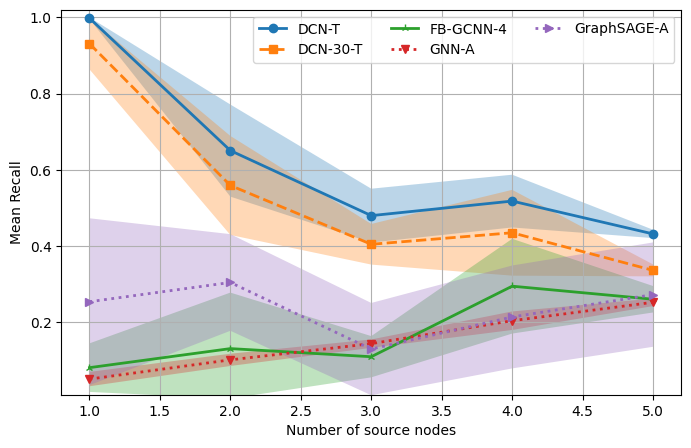

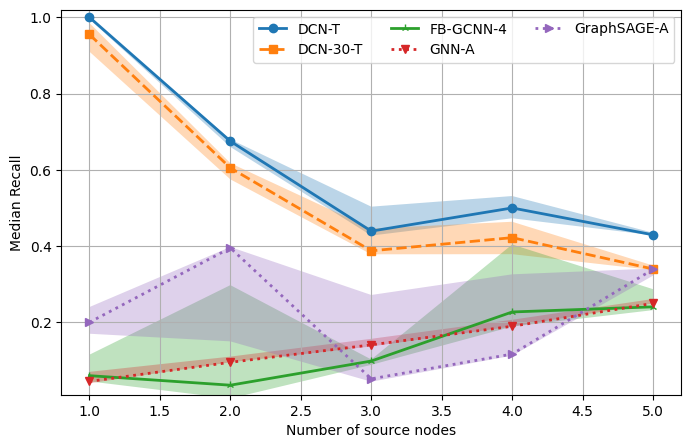

In [ ]:
# Plotting

# Plot Mean + Std for Recall
utils.plot_results(mean_rec_all, n_sources_list, restricted_exps, 
                   xlabel='Number of source nodes', 
                   ylabel='Mean Recall', 
                   logy=False, 
                   std=std_rec_all,
                   ylim_top=1.02,
                   n_cols=3)

# Plot Median + Percentiles (25, 75) for Recall
utils.plot_results(med_rec_all, n_sources_list, restricted_exps, 
                   xlabel='Number of source nodes', 
                   ylabel='Median Recall', 
                   logy=False,
                   prctile_low=p25_rec_all, 
                   prctile_up=p75_rec_all,
                   ylim_top=1.02,
                   n_cols=3)
